# POC: End-to-End Anti-Spoofing — Full Subset

This notebook downloads **ASVspoof 2019 LA** dataset, extracts **LFCC** features,
trains a lightweight **LCNN**, and reports **EER** — all in one place.

**Pipeline:**
1. Download dataset or use the one already available
2. Extract LFCC features (60-dim: 20 static + 20 delta + 20 delta-delta)
3. Train an LCNN (~54K params) for 30 epochs
4. Compute EER on the dev set
5. Generate report plots (training curves, score distribution, per-attack EER)
6. Print a clean summary

> **Install once:** `pip install datasets soundfile numpy scipy matplotlib torch torchaudio scikit-learn`

## Imports

In [59]:
import os
import json
import time
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from scipy.fft import dct

%matplotlib inline

## Configuration

Tweak these to scale up. The defaults run end-to-end in ~5–15 minutes on CPU.

**Scaling presets:**
- *Tiny POC (default):* `n_bonafide_train=50`, `n_spoof_per_attack_train=9`, `epochs=20` → ~160 samples
- *Medium:* `n_bonafide_train=200`, `n_spoof_per_attack_train=33`, `epochs=30` → ~400 samples
- *Full balanced:* `n_bonafide_train=2580`, `n_spoof_per_attack_train=430`, `epochs=50` → ~5000 samples

In [60]:
CONFIG = {
    # Data
    # FULL ASVspoof 2019 LA partitions. Counts are set ABOVE the real
    # maximums so the selection loop takes every available utterance.
    "n_bonafide_train": 2580,        # all train bonafide (~2580)
    "n_spoof_per_attack_train": 4000,# train: 6 attacks (~3800 each) -> takes all
    "n_bonafide_dev": 2548,          # all dev bonafide (~2548)
    "n_spoof_per_attack_dev": 4000,  # dev: 6 attacks -> takes all
    "n_bonafide_eval": 7355,         # all eval bonafide (~7355)
    "n_spoof_per_attack_eval": 5000, # eval: 13 attacks (~4900 each) -> takes all
    "max_audio_sec": 4.0,          # pad/truncate audio to this length

    # LFCC
    "sample_rate": 16000,
    "n_lfcc": 20,
    "n_filters": 20,
    "n_fft": 512,
    "frame_ms": 20.0,
    "hop_ms": 10.0,
    "max_frames": 400,             # pad/truncate feature frames

    # Training
    "batch_size": 32,
    "epochs": 30,
    "lr": 0.0001,
    "weight_decay": 1e-4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # Paths
    "data_dir": "poc_data",
    "output_dir": "poc_results",

    "model": None,
    "history": None,
    "all_scores": None,
    "all_labels": None,
    "all_systems": None
}

# Pipeline control flags — set True to skip steps you've already run
SKIP_DOWNLOAD = True
SKIP_EXTRACT = True

# Path to your existing ASVspoof 2019 LA folder
LA_ROOT = r"C:\\DL\\archive\\LA\\"   # ← edit this to point at the LA folder

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(f"Device: {CONFIG['device']}")
print(f"Train target: {CONFIG['n_bonafide_train']} bonafide + {CONFIG['n_spoof_per_attack_train']*6} spoof")
print(f"Dev target:   {CONFIG['n_bonafide_dev']} bonafide + {CONFIG['n_spoof_per_attack_dev']*6} spoof")
print(f"Eval target:  {CONFIG['n_bonafide_eval']} bonafide + {CONFIG['n_spoof_per_attack_eval']*13} spoof (unseen attacks A07-A19)")

Device: cuda
Train target: 2580 bonafide + 24000 spoof
Dev target:   2548 bonafide + 24000 spoof
Eval target:  7355 bonafide + 65000 spoof (unseen attacks A07-A19)


## Step 1 — Download a small balanced subset

Streams the ASVspoof 2019 LA dataset from HuggingFace and saves only the audio files we need
to disk as `.flac`, with a `protocol.txt` listing labels and attack types.

The dataset has 6 spoof attacks (A01–A04 = TTS, A05–A06 = VC). We pull a fixed number from
each so both classes — and all attack types — are represented.

In [61]:
import shutil
import random

# Maps each split to its source audio dir and protocol file inside LA_ROOT.
def _split_paths(split):
    if split == "train":
        return ("ASVspoof2019_LA_train", "ASVspoof2019.LA.cm.train.trn.txt")
    elif split == "dev":
        return ("ASVspoof2019_LA_dev", "ASVspoof2019.LA.cm.dev.trl.txt")
    elif split == "eval":
        return ("ASVspoof2019_LA_eval", "ASVspoof2019.LA.cm.eval.trl.txt")
    raise ValueError(f"Unknown split: {split}")


def download_subset(config, split="train"):
    """Select a balanced subset and write only the protocol file.

    NOTE: this version does NOT copy any audio. Because the full ASVspoof
    LA dataset already exists locally at LA_ROOT, copying ~140k flac files
    would waste time and several GB of disk. Instead we write a protocol
    listing the chosen utterances, and process_split() reads the flac
    directly from LA_ROOT.
    """
    if split == "train":
        n_bonafide = config["n_bonafide_train"]
        n_spoof = config["n_spoof_per_attack_train"]
    elif split == "dev":
        n_bonafide = config["n_bonafide_dev"]
        n_spoof = config["n_spoof_per_attack_dev"]
    elif split == "eval":
        n_bonafide = config["n_bonafide_eval"]
        n_spoof = config["n_spoof_per_attack_eval"]
    else:
        raise ValueError(f"Unknown split: {split}")

    audio_subdir, protocol_name = _split_paths(split)
    src_audio_dir = os.path.join(LA_ROOT, audio_subdir, "flac")
    src_protocol = os.path.join(LA_ROOT, "ASVspoof2019_LA_cm_protocols",
                                protocol_name)

    if not os.path.isdir(src_audio_dir):
        raise FileNotFoundError(
            f"Could not find {src_audio_dir}\n"
            f"Check LA_ROOT and that your folder uses the official structure."
        )
    if not os.path.isfile(src_protocol):
        raise FileNotFoundError(f"Could not find protocol file: {src_protocol}")

    os.makedirs(os.path.join(config["data_dir"], split), exist_ok=True)
    protocol_path = os.path.join(config["data_dir"], split, "protocol.txt")

    if os.path.isfile(protocol_path):
        n_existing = sum(1 for _ in open(protocol_path))
        if n_existing > 10:
            print(f"  [{split}] Found existing protocol ({n_existing} lines), "
                  f"skipping selection")
            return

    print(f"  [{split}] Selecting from {src_audio_dir}")

    # Read protocol
    all_entries = []
    with open(src_protocol) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                all_entries.append({
                    "speaker_id": parts[0],
                    "audio_id": parts[1],
                    "system_id": parts[3],
                    "label": parts[4],
                })

    # attack ids actually present (train/dev: A01-A06; eval: A07-A19)
    all_attacks = {e["system_id"] for e in all_entries
                   if e["label"] != "bonafide"}
    print(f"    {len(all_attacks)} attack types in this split: "
          f"{', '.join(sorted(all_attacks))}")

    random.seed(42)
    random.shuffle(all_entries)

    bonafide_count = 0
    spoof_counts = defaultdict(int)
    protocol_lines = []

    for entry in all_entries:
        is_bonafide = entry["label"] == "bonafide"
        sys_id = entry["system_id"]

        keep = False
        if is_bonafide and bonafide_count < n_bonafide:
            keep = True
            bonafide_count += 1
        elif not is_bonafide and spoof_counts[sys_id] < n_spoof:
            keep = True
            spoof_counts[sys_id] += 1

        if not keep:
            done = bonafide_count >= n_bonafide and len(all_attacks) > 0 and all(
                spoof_counts.get(a, 0) >= n_spoof for a in all_attacks
            )
            if done:
                break
            continue

        # only record the utterance if its flac actually exists on disk
        src_file = os.path.join(src_audio_dir, f"{entry['audio_id']}.flac")
        if os.path.exists(src_file):
            protocol_lines.append(
                f"{entry['speaker_id']} {entry['audio_id']} - "
                f"{entry['system_id']} {entry['label']}"
            )

    with open(protocol_path, "w") as f:
        f.write("\n".join(protocol_lines))

    print(f"  [{split}] Selected {len(protocol_lines)} utterances "
          f"({bonafide_count} bonafide, {sum(spoof_counts.values())} spoof)")
    for sys_id in sorted(spoof_counts):
        print(f"    {sys_id}: {spoof_counts[sys_id]}")


In [62]:
# Run the download
if not SKIP_DOWNLOAD:
    print("=" * 60)
    print("STEP 1: Downloading data")
    print("=" * 60)
    download_subset(CONFIG, split="train")
    download_subset(CONFIG, split="dev")
    download_subset(CONFIG, split="eval")
else:
    print("Skipped (SKIP_DOWNLOAD=True)")

Skipped (SKIP_DOWNLOAD=True)


## Step 2 — LFCC feature extraction

**LFCC (Linear Frequency Cepstral Coefficients)** are similar to MFCCs but use a *linear* filterbank
instead of a mel-scaled one. For anti-spoofing this matters — synthesis artifacts often appear
in higher frequencies that a mel scale would compress.

The feature pipeline per audio clip:

1. **Pre-emphasis** (boost high frequencies)
2. **Framing** with Hamming window (20 ms frame, 10 ms hop)
3. **Power spectrum** via FFT
4. **Linear filterbank** (20 triangular filters)
5. **Log + DCT** → 20 cepstral coefficients
6. **Deltas** and **delta-deltas** → 60-dim total

Each clip becomes a `(60, n_frames)` matrix, padded/truncated to 400 frames.

In [63]:
def extract_lfcc(waveform, config):
    """Extract LFCC features from a 1D waveform array."""
    sr = config["sample_rate"]
    n_filters = config["n_filters"]
    n_ceps = config["n_lfcc"]
    n_fft = config["n_fft"]
    frame_len = int(sr * config["frame_ms"] / 1000)
    frame_hop = int(sr * config["hop_ms"] / 1000)

    # Pre-emphasis
    emphasized = np.append(waveform[0], waveform[1:] - 0.97 * waveform[:-1])

    # Framing
    n_frames = 1 + (len(emphasized) - frame_len) // frame_hop
    if n_frames < 1:
        n_frames = 1
        emphasized = np.pad(emphasized, (0, frame_len - len(emphasized)))

    indices = np.arange(frame_len)[None, :] + np.arange(n_frames)[:, None] * frame_hop
    frames = emphasized[indices] * np.hamming(frame_len)

    # FFT → power spectrum
    power = (1.0 / n_fft) * np.abs(np.fft.rfft(frames, n=n_fft)) ** 2

    # Linear filterbank
    freq_points = np.linspace(0, sr / 2, n_filters + 2)
    bin_points = np.floor((n_fft + 1) * freq_points / sr).astype(int)
    fbank = np.zeros((n_filters, n_fft // 2 + 1))
    for i in range(n_filters):
        for j in range(bin_points[i], bin_points[i + 1]):
            fbank[i, j] = (j - bin_points[i]) / max(1, bin_points[i + 1] - bin_points[i])
        for j in range(bin_points[i + 1], bin_points[i + 2]):
            fbank[i, j] = (bin_points[i + 2] - j) / max(1, bin_points[i + 2] - bin_points[i + 1])

    # Log filterbank energies → DCT
    energies = np.dot(power, fbank.T)
    energies = np.where(energies == 0, np.finfo(float).eps, energies)
    log_energies = np.log(energies)
    cepstral = dct(log_energies, type=2, axis=1, norm="ortho")[:, :n_ceps].T

    # Deltas
    def _delta(feat, w=2):
        denom = 2 * sum(n**2 for n in range(1, w + 1))
        padded = np.pad(feat, ((0, 0), (w, w)), mode="edge")
        d = np.zeros_like(feat)
        for t in range(feat.shape[1]):
            for n in range(1, w + 1):
                d[:, t] += n * (padded[:, t + w + n] - padded[:, t + w - n])
            d[:, t] /= denom
        return d

    delta = _delta(cepstral)
    delta_delta = _delta(delta)

    return np.concatenate([cepstral, delta, delta_delta], axis=0)  # (60, n_frames)


def process_split(config, split):
    """Extract LFCC for all files in a split.

    Reads flac directly from LA_ROOT (no local copy needed)."""
    import soundfile as sf

    audio_subdir, _ = _split_paths(split)
    flac_dir = os.path.join(LA_ROOT, audio_subdir, "flac")
    protocol_path = os.path.join(config["data_dir"], split, "protocol.txt")
    feat_dir = os.path.join(config["data_dir"], split, "features")
    os.makedirs(feat_dir, exist_ok=True)

    existing_npy = [f for f in os.listdir(feat_dir) if f.endswith(".npy")]
    if len(existing_npy) > 10:
        print(f"  [{split}] Found {len(existing_npy)} existing feature files, skipping extraction")
        return

    entries = []
    with open(protocol_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                entries.append({
                    "speaker_id": parts[0],
                    "audio_id": parts[1],
                    "system_id": parts[3],
                    "label": parts[4],
                })

    labels = []
    target_len = int(config["sample_rate"] * config["max_audio_sec"])

    print(f"  [{split}] Extracting LFCC for {len(entries)} utterances...")
    for idx, entry in enumerate(entries):
        if idx > 0 and idx % 2000 == 0:
            print(f"    {idx}/{len(entries)} done")
        path = os.path.join(flac_dir, f"{entry['audio_id']}.flac")
        if not os.path.exists(path):
            continue

        wav, sr = sf.read(path, dtype="float32")
        if wav.ndim > 1:        # downmix in the unlikely event of stereo
            wav = wav.mean(axis=1)

        # Pad/truncate
        if len(wav) > target_len:
            wav = wav[:target_len]
        elif len(wav) < target_len:
            wav = np.pad(wav, (0, target_len - len(wav)))

        lfcc = extract_lfcc(wav, config)

        np.save(os.path.join(feat_dir, f"{entry['audio_id']}.npy"), lfcc)
        labels.append({
            "audio_id": entry["audio_id"],
            "label": 1 if entry["label"] == "bonafide" else 0,
            "system_id": entry["system_id"],
        })

    with open(os.path.join(feat_dir, "labels.json"), "w") as f:
        json.dump(labels, f)

    print(f"  [{split}] Extracted {len(labels)} features → {feat_dir}/")

In [64]:
# Run the extraction
if not SKIP_EXTRACT:
    print("=" * 60)
    print("STEP 2: Extracting LFCC features")
    print("=" * 60)
    process_split(CONFIG, "train")
    process_split(CONFIG, "dev")
    process_split(CONFIG, "eval")
else:
    print("Skipped (SKIP_EXTRACT=True)")

Skipped (SKIP_EXTRACT=True)


### Sanity check — visualize one LFCC sample

Quick look at what the model will actually see.

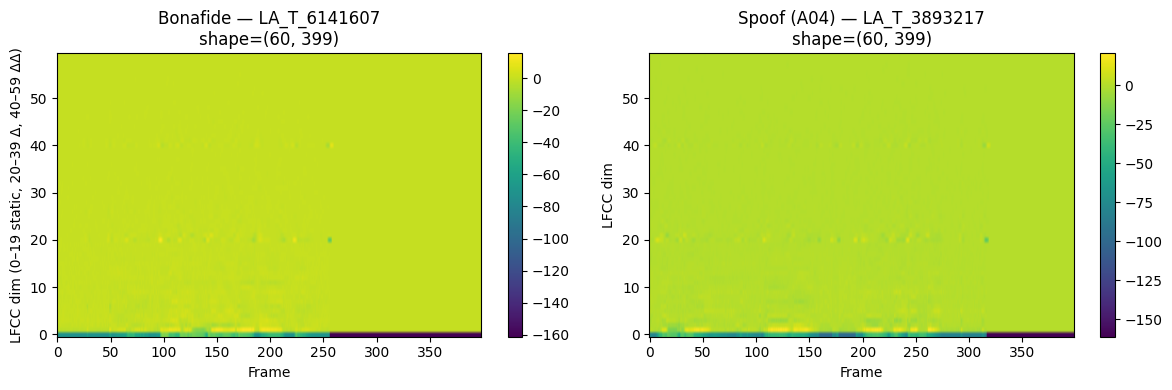

In [65]:
# Visualize one bonafide and one spoof sample
feat_dir = os.path.join(CONFIG["data_dir"], "train", "features")
with open(os.path.join(feat_dir, "labels.json")) as f:
    sample_labels = json.load(f)

bonafide_sample = next(s for s in sample_labels if s["label"] == 1)
spoof_sample = next(s for s in sample_labels if s["label"] == 0)

bonafide_lfcc = np.load(os.path.join(feat_dir, f"{bonafide_sample['audio_id']}.npy"))
spoof_lfcc = np.load(os.path.join(feat_dir, f"{spoof_sample['audio_id']}.npy"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(bonafide_lfcc, aspect="auto", origin="lower", cmap="viridis")
axes[0].set_title(f"Bonafide — {bonafide_sample['audio_id']}\nshape={bonafide_lfcc.shape}")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("LFCC dim (0–19 static, 20–39 Δ, 40–59 ΔΔ)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(spoof_lfcc, aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title(f"Spoof ({spoof_sample['system_id']}) — {spoof_sample['audio_id']}\nshape={spoof_lfcc.shape}")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("LFCC dim")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

## Step 3 — PyTorch `Dataset`

Loads cached `.npy` features and pads/truncates each one to a fixed `max_frames` width
so they can be batched together. Returns `(tensor, label, system_id)` tuples — `system_id`
is carried through so we can do per-attack analysis later.

In [66]:
class LFCCDataset(Dataset):
    def __init__(self, feat_dir, max_frames=400):
        with open(os.path.join(feat_dir, "labels.json")) as f:
            self.labels = json.load(f)
        self.feat_dir = feat_dir
        self.max_frames = max_frames

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        entry = self.labels[idx]
        lfcc = np.load(os.path.join(self.feat_dir, f"{entry['audio_id']}.npy"))

        # Pad/truncate width
        _, n_frames = lfcc.shape
        if n_frames > self.max_frames:
            lfcc = lfcc[:, :self.max_frames]
        elif n_frames < self.max_frames:
            lfcc = np.pad(lfcc, ((0, 0), (0, self.max_frames - n_frames)))

        tensor = torch.FloatTensor(lfcc).unsqueeze(0)  # (1, 60, max_frames)
        label = entry["label"]
        system_id = entry.get("system_id", "-")

        return tensor, label, system_id

## Step 4 — Lightweight CNN (LCNN)

A 5-block conv network with **Max Feature Map (MFM)** activation instead of ReLU.
MFM splits the channel dimension in half and takes the element-wise max of the two halves —
a competitive gating mechanism that keeps only the most discriminative features. This is
particularly useful when training data is limited.

```
Input: (batch, 1, 60, 400)
  Conv(1→32) → BN → MFM → MaxPool   →  (batch, 16, 30, 200)
  Conv(16→32) → BN → MFM → MaxPool  →  (batch, 16, 15, 100)
  Conv(16→64) → BN → MFM → MaxPool  →  (batch, 32, 7, 50)
  Conv(32→64) → BN → MFM            →  (batch, 32, 7, 50)
  Conv(32→64) → BN → MFM            →  (batch, 32, 7, 50)
GlobalAvgPool → FC(32→64) → ReLU → Dropout(0.3) → FC(64→2)
Output: 2 class logits
```

~200K parameters total.

In [67]:
class MaxFeatureMap(nn.Module):
    """Max Feature Map activation — splits channels in half, takes element-wise max."""
    def forward(self, x):
        a, b = x.chunk(2, dim=1)
        return torch.max(a, b)


class LightCNN(nn.Module):
    """
    Lightweight CNN for anti-spoofing.
    5 conv blocks with MFM activation -> global avg pool -> FC classifier.
    ~200K parameters - trains fast even on CPU.
    """
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            MaxFeatureMap(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            MaxFeatureMap(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(16, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            MaxFeatureMap(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            MaxFeatureMap(),

            # Block 5
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            MaxFeatureMap(),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


# Quick parameter count
_m = LightCNN()
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"LightCNN parameters: {n_params:,}")
del _m

LightCNN parameters: 53,986


## Step 5 — Evaluation metrics

### Equal Error Rate (EER)

The standard ASVspoof metric. EER is the point on the ROC curve where the **False Acceptance Rate**
(spoof samples wrongly accepted as bonafide) equals the **False Rejection Rate**
(bonafide samples wrongly rejected as spoof).

Lower is better. An EER of 0% means perfect separation; 50% means random guessing.

### Per-attack EER

We also break EER down by attack type (A01–A06) — this shows which spoofing methods
the model finds easy vs. hard.

In [68]:
def compute_eer(labels, scores):
    """
    Compute Equal Error Rate (EER).
    EER is the point where FAR = FRR. Standard ASVspoof metric.
    """
    from sklearn.metrics import roc_curve

    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr

    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2 * 100  # percentage

    return eer


def per_attack_analysis(scores, labels, systems):
    """Break down performance by attack type."""
    results = {}

    bonafide_scores = [s for s, l in zip(scores, labels) if l == 1]

    attack_scores = defaultdict(list)
    for s, l, sys_id in zip(scores, labels, systems):
        if l == 0:
            attack_scores[sys_id].append(s)

    for attack_id in sorted(attack_scores.keys()):
        attack_s = attack_scores[attack_id]
        combined_labels = [1] * len(bonafide_scores) + [0] * len(attack_s)
        combined_scores = bonafide_scores + attack_s

        if len(set(combined_labels)) < 2:
            results[attack_id] = {"eer": float("nan"), "n_samples": len(attack_s)}
            continue

        eer = compute_eer(np.array(combined_labels), np.array(combined_scores))
        results[attack_id] = {
            "eer": eer,
            "n_samples": len(attack_s),
            "mean_score": np.mean(attack_s),
        }

    return results

## Step 6 — Train the LCNN

Trains for `CONFIG["epochs"]` epochs with:
- **Adam optimizer** (`lr=1e-4`, `weight_decay=1e-4`)
- **Weighted cross-entropy** to handle the slight bonafide/spoof imbalance
- **Per-epoch dev evaluation** with EER, accuracy, and loss

You should see train loss decrease steadily and dev EER come down. With only ~100 training
samples expect dev EER around **15–35%**.

In [69]:
def train_model(config):
    """Train the LCNN and return training history."""
    device = config["device"]
    print(f"  Device: {device}")

    train_ds = LFCCDataset(
        os.path.join(config["data_dir"], "train", "features"),
        max_frames=config["max_frames"],
    )
    dev_ds = LFCCDataset(
        os.path.join(config["data_dir"], "dev", "features"),
        max_frames=config["max_frames"],
    )

    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
    dev_loader = DataLoader(dev_ds, batch_size=config["batch_size"], shuffle=False)

    print(f"  Train: {len(train_ds)} samples ({sum(1 for l in train_ds.labels if l['label']==1)} bonafide, "
          f"{sum(1 for l in train_ds.labels if l['label']==0)} spoof)")
    print(f"  Dev:   {len(dev_ds)} samples ({sum(1 for l in dev_ds.labels if l['label']==1)} bonafide, "
          f"{sum(1 for l in dev_ds.labels if l['label']==0)} spoof)")

    model = LightCNN(in_channels=1, num_classes=2).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Model parameters: {n_params:,}")

    # Class weights for imbalance.
    # CrossEntropyLoss expects weight[i] = weight for CLASS i.
    # Class index 0 = spoof, class index 1 = bonafide.
    # Use INVERSE frequency so the rarer class gets the larger weight.
    n_bonafide = sum(1 for l in train_ds.labels if l["label"] == 1)
    n_spoof = sum(1 for l in train_ds.labels if l["label"] == 0)
    total = n_bonafide + n_spoof
    weight = torch.FloatTensor([
        total / (2.0 * n_spoof),      # index 0 -> spoof
        total / (2.0 * n_bonafide),   # index 1 -> bonafide
    ]).to(device)
    print(f"  Class weights [spoof, bonafide]: "
          f"[{weight[0]:.3f}, {weight[1]:.3f}]")
    criterion = nn.CrossEntropyLoss(weight=weight)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                     factor=0.5, patience=5)

    history = {"train_loss": [], "dev_loss": [], "dev_acc": [], "dev_eer": [],
               "epoch_time": []}

    for epoch in range(config["epochs"]):
        epoch_start = time.time()
        # --- Train ---
        model.train()
        train_loss = 0
        for features, labels, _ in train_loader:
            features = features.to(device)
            labels = torch.LongTensor(labels).to(device)

            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # --- Evaluate ---
        model.eval()
        dev_loss = 0
        all_scores = []
        all_labels = []
        all_systems = []

        with torch.no_grad():
            for features, labels, systems in dev_loader:
                features = features.to(device)
                labels_tensor = torch.LongTensor(labels).to(device)

                outputs = model(features)
                loss = criterion(outputs, labels_tensor)
                dev_loss += loss.item()

                scores = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
                all_scores.extend(scores)
                all_labels.extend(labels)
                all_systems.extend(systems)

        dev_loss /= len(dev_loader)

        eer = compute_eer(np.array(all_labels), np.array(all_scores))
        preds = (np.array(all_scores) > 0.5).astype(int)
        acc = (preds == np.array(all_labels)).mean() * 100

        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_loss)
        history["dev_acc"].append(acc)
        history["dev_eer"].append(eer)
        epoch_time = time.time() - epoch_start
        history["epoch_time"].append(epoch_time)
        scheduler.step(dev_loss)

        # Save model
        CONFIG["model"] = model
        CONFIG["history"] = history
        CONFIG["scores"] = scores
        CONFIG["labels"] = labels
        CONFIG["systems"] = systems

        print(f"  Epoch {epoch+1:2d}/{config['epochs']} | "
              f"Train loss: {train_loss:.4f} | "
              f"Dev loss: {dev_loss:.4f} | "
              f"Dev acc: {acc:.1f}% | "
              f"Dev EER: {eer:.2f}% | "
              f"Time: {epoch_time:.1f}s")

    model_path = os.path.join(config["output_dir"], "lcnn_poc.pth")
    torch.save(model.state_dict(), model_path)
    print(f"\n  Model saved: {model_path}")
    best_ep = int(np.argmin(history["dev_eer"]))
    best_val = history["dev_eer"][best_ep]
    print(f"  Best dev EER: {best_val:.2f}% (epoch {best_ep + 1})")
    avg_t = sum(history["epoch_time"]) / len(history["epoch_time"])
    print(f"  Avg epoch time: {avg_t:.1f}s | "
          f"Total training time: {sum(history['epoch_time']):.0f}s")

    return model, history, all_scores, all_labels, all_systems

In [70]:
# Run training
print("=" * 60)
print("STEP 3: Training LCNN")
print("=" * 60)

t_start = time.time()
model, history, scores, labels, systems = train_model(CONFIG)
print(f"\n  Training time: {time.time() - t_start:.0f} seconds")

STEP 3: Training LCNN
  Device: cuda
  Train: 25380 samples (2580 bonafide, 22800 spoof)
  Dev:   24844 samples (2548 bonafide, 22296 spoof)
  Model parameters: 53,986
  Class weights [spoof, bonafide]: [0.557, 4.919]
  Epoch  1/30 | Train loss: 0.4446 | Dev loss: 0.3613 | Dev acc: 91.9% | Dev EER: 11.69% | Time: 406.2s
  Epoch  2/30 | Train loss: 0.1900 | Dev loss: 0.1985 | Dev acc: 87.7% | Dev EER: 6.67% | Time: 288.0s
  Epoch  3/30 | Train loss: 0.1094 | Dev loss: 0.1306 | Dev acc: 96.9% | Dev EER: 4.31% | Time: 287.6s
  Epoch  4/30 | Train loss: 0.0751 | Dev loss: 0.0920 | Dev acc: 97.4% | Dev EER: 3.51% | Time: 290.8s
  Epoch  5/30 | Train loss: 0.0519 | Dev loss: 0.0798 | Dev acc: 97.8% | Dev EER: 2.91% | Time: 294.6s
  Epoch  6/30 | Train loss: 0.0430 | Dev loss: 0.8517 | Dev acc: 94.3% | Dev EER: 2.83% | Time: 294.8s
  Epoch  7/30 | Train loss: 0.0331 | Dev loss: 0.0490 | Dev acc: 99.0% | Dev EER: 1.56% | Time: 290.7s
  Epoch  8/30 | Train loss: 0.0287 | Dev loss: 0.0567 | Dev 

## Step 6b - Evaluate on the held-out eval set (unseen attacks)

The dev EER above is measured on attacks **A01-A06**, which the model also trained on - that is *in-distribution* performance.

This step runs the trained model on the **eval set**, whose attacks **A07-A19 were never seen during training**. This is the number that is directly comparable to the RawNet2 result, since RawNet2 is also scored on this same eval set. Expect the eval EER to be **higher** (worse) than the dev EER - the gap is exactly the generalisation challenge the project is about.

In [71]:
@torch.no_grad()
def evaluate_on_eval(model, config):
    """Run the trained model on the held-out eval set (unseen attacks)."""
    device = config["device"]
    model.eval()

    eval_ds = LFCCDataset(
        os.path.join(config["data_dir"], "eval", "features"),
        max_frames=config["max_frames"],
    )
    eval_loader = DataLoader(eval_ds, batch_size=config["batch_size"], shuffle=False)

    n_bona = sum(1 for l in eval_ds.labels if l["label"] == 1)
    n_spoof = sum(1 for l in eval_ds.labels if l["label"] == 0)
    print(f"  Eval set: {len(eval_ds)} samples ({n_bona} bonafide, {n_spoof} spoof)")

    all_scores, all_labels, all_systems = [], [], []
    for features, labels, systems in eval_loader:
        features = features.to(device)
        outputs = model(features)
        scores = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        all_scores.extend(scores)
        all_labels.extend(labels)
        all_systems.extend(systems)

    eval_eer = compute_eer(np.array(all_labels), np.array(all_scores))
    preds = (np.array(all_scores) > 0.5).astype(int)
    eval_acc = (preds == np.array(all_labels)).mean() * 100

    print(f"\n  Eval accuracy : {eval_acc:.1f}%")
    print(f"  Eval EER      : {eval_eer:.2f}%   <-- comparable to RawNet2")
    return eval_eer, eval_acc, all_scores, all_labels, all_systems


print("=" * 60)
print("STEP 6b: Evaluating on held-out eval set (unseen attacks)")
print("=" * 60)
eval_eer, eval_acc, eval_scores, eval_labels, eval_systems = evaluate_on_eval(model, CONFIG)

# per-attack EER on the UNSEEN attacks A07-A19
print("\n  Per-attack EER on unseen attacks:")
eval_attack_results = per_attack_analysis(eval_scores, eval_labels, eval_systems)
for atk in sorted(eval_attack_results.keys()):
    r = eval_attack_results[atk]
    print(f"    {atk}: EER = {r['eer']:5.2f}%   (n_spoof = {r['n_samples']})")


STEP 6b: Evaluating on held-out eval set (unseen attacks)
  Eval set: 71237 samples (7355 bonafide, 63882 spoof)

  Eval accuracy : 91.5%
  Eval EER      : 4.46%   <-- comparable to RawNet2

  Per-attack EER on unseen attacks:
    A07: EER =  0.97%   (n_spoof = 4914)
    A08: EER =  0.73%   (n_spoof = 4914)
    A09: EER =  0.00%   (n_spoof = 4914)
    A10: EER =  1.55%   (n_spoof = 4914)
    A11: EER =  0.06%   (n_spoof = 4914)
    A12: EER =  1.47%   (n_spoof = 4914)
    A13: EER =  1.03%   (n_spoof = 4914)
    A14: EER =  1.37%   (n_spoof = 4914)
    A15: EER =  0.41%   (n_spoof = 4914)
    A16: EER =  0.90%   (n_spoof = 4914)
    A17: EER = 19.64%   (n_spoof = 4914)
    A18: EER =  7.80%   (n_spoof = 4914)
    A19: EER =  5.09%   (n_spoof = 4914)


## Step 6c - Write the CM score file for min t-DCF

EER above only needs this model. **min t-DCF** additionally needs the organizers' reference ASV scores, so it is computed by the official `evaluate_tDCF_asvspoof19.py` script, not in this notebook.

This cell writes a **CM score file** in the official 4-column format:

```
UTT_ID   ATTACK_ID   KEY        SCORE
LA_E_..  -           bonafide   0.9912
LA_E_..  A17         spoof      0.0488
```

Then, **outside the notebook**, run:

```
python evaluate_tDCF_asvspoof19.py cm_eval_lcnn_scores.txt \\
    <LA_ROOT>/ASVspoof2019_LA_asv_scores/ASVspoof2019.LA.asv.eval.gi.trl.scores.txt
```

You also need `eval_metrics.py` from the official ASVspoof package beside the script. It prints both CM EER and min t-DCF.

In [76]:
@torch.no_grad()
def write_cm_score_file(model, config, out_path="cm_eval_lcnn_scores.txt"):
    """Write a CM score file in the official ASVspoof 2019 format.

    Columns: UTT_ID  ATTACK_ID  KEY  SCORE   (higher SCORE => more bonafide).

    The eval DataLoader uses shuffle=False, so model outputs line up
    with eval_ds.labels in order -- we read UTT_IDs from there.
    """
    device = config["device"]
    model.eval()

    eval_ds = LFCCDataset(
        os.path.join(config["data_dir"], "eval", "features"),
        max_frames=config["max_frames"],
    )
    eval_loader = DataLoader(eval_ds, batch_size=config["batch_size"],
                             shuffle=False)

    scores = []
    for features, _, _ in eval_loader:
        features = features.to(device)
        outputs = model(features)
        # P(bonafide) = softmax class-1 prob; higher => more bonafide
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        scores.extend(probs)

    assert len(scores) == len(eval_ds.labels), \
        "score count must match eval label count (loader must not shuffle)"

    n_written = 0
    with open(out_path, "w") as f:
        for entry, score in zip(eval_ds.labels, scores):
            utt_id = entry["audio_id"]
            key = "bonafide" if entry["label"] == 1 else "spoof"
            atk = "-" if entry["label"] == 1 else entry.get("system_id", "-")
            f.write(f"{utt_id} {atk} {key} {score:.6f}\n")
            n_written += 1

    print(f"  Wrote {n_written} CM scores -> {out_path}")
    return out_path


cm_score_path = write_cm_score_file(model, CONFIG, "cm_eval_lcnn_scores.txt")

# preview the first few lines
print("\n  Preview:")
with open(cm_score_path) as f:
    for _ in range(5):
        print("   ", f.readline().rstrip())


  Wrote 71237 CM scores -> cm_eval_lcnn_scores.txt

  Preview:
    LA_E_2184116 A18 spoof 0.997357
    LA_E_1091053 A09 spoof 0.000000
    LA_E_3814350 A09 spoof 0.000000
    LA_E_6561636 A16 spoof 0.000080
    LA_E_1107470 A08 spoof 0.000000


## Step 7 — Report plots

Three figures for the mid-report:

1. **Training curves** — train/dev loss + dev EER over epochs (shows the model is learning)
2. **Score distribution** — histogram of bonafide vs spoof scores (shows class separation)
3. **Per-attack EER** — bar chart of EER per attack type (shows which attacks are harder)

All three are also saved to `poc_results/` for inclusion in the report.

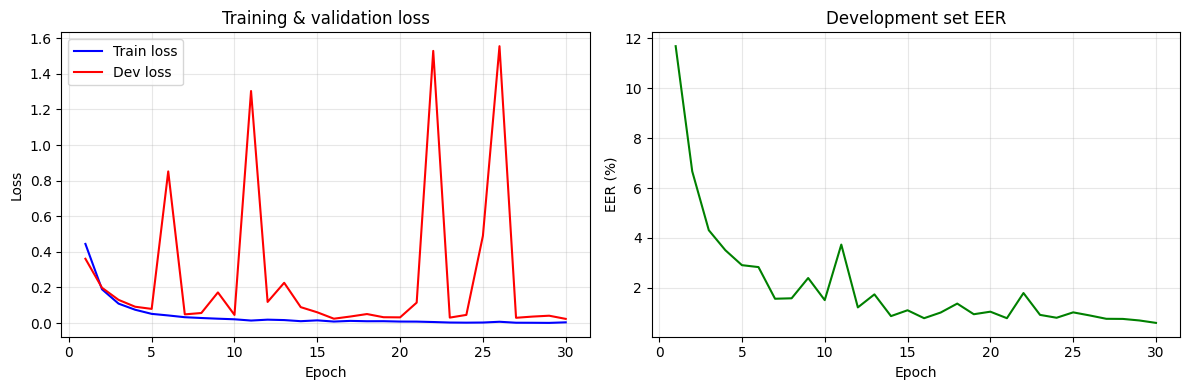

In [72]:
# --- Plot 1: Training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_x = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_x, history["train_loss"], "b-", label="Train loss", linewidth=1.5)
ax1.plot(epochs_x, history["dev_loss"], "r-", label="Dev loss", linewidth=1.5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & validation loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_x, history["dev_eer"], "g-", linewidth=1.5)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("EER (%)")
ax2.set_title("Development set EER")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

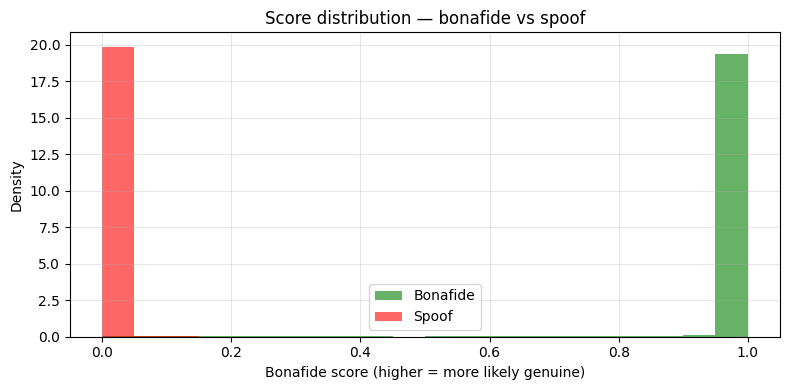

In [73]:
# --- Plot 2: Score distribution ---
fig, ax = plt.subplots(figsize=(8, 4))

bonafide_scores = [s for s, l in zip(scores, labels) if l == 1]
spoof_scores = [s for s, l in zip(scores, labels) if l == 0]

ax.hist(bonafide_scores, bins=20, alpha=0.6, label="Bonafide", color="green", density=True)
ax.hist(spoof_scores, bins=20, alpha=0.6, label="Spoof", color="red", density=True)
ax.set_xlabel("Bonafide score (higher = more likely genuine)")
ax.set_ylabel("Density")
ax.set_title("Score distribution — bonafide vs spoof")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "score_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

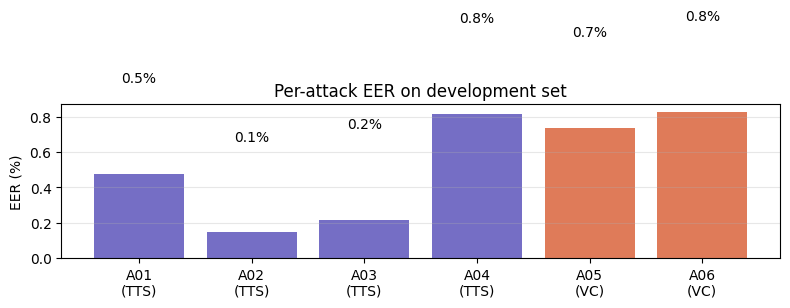

In [74]:
# --- Plot 3: Per-attack EER ---
attack_results = per_attack_analysis(scores, labels, systems)

if attack_results:
    fig, ax = plt.subplots(figsize=(8, 4))

    attacks = sorted(attack_results.keys())
    eers = [attack_results[a]["eer"] for a in attacks]
    colors = ["#1D9E75" if a.startswith("-") else
              "#534AB7" if a in ["A01", "A02", "A03", "A04"] else
              "#D85A30" for a in attacks]
    labels_text = [f"{a}\n({'TTS' if a in ['A01','A02','A03','A04'] else 'VC'})"
                   if a != "-" else "bonafide" for a in attacks]

    bars = ax.bar(labels_text, eers, color=colors, alpha=0.8)
    ax.set_ylabel("EER (%)")
    ax.set_title("Per-attack EER on development set")
    ax.grid(True, alpha=0.3, axis="y")

    for bar, eer_val in zip(bars, eers):
        if not np.isnan(eer_val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f"{eer_val:.1f}%", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG["output_dir"], "per_attack_eer.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Not enough per-attack data for breakdown plot.")

## Step 8 — Final summary

Prints a clean summary suitable for the mid-report and saves all numbers to `results.json`.

In [ ]:
def print_summary(config, history, scores, labels, systems):
    """Print a clean summary suitable for the mid-report."""
    best_epoch = int(np.argmin(history["dev_eer"]))
    best_eer = history["dev_eer"][best_epoch]
    best_acc = history["dev_acc"][best_epoch]

    attack_results = per_attack_analysis(scores, labels, systems)

    print("\n" + "=" * 60)
    print("  PRELIMINARY RESULTS SUMMARY")
    print("=" * 60)
    print(f"\n  Model:          Lightweight CNN (LCNN) with MFM activation")
    print(f"  Features:       LFCC (60-dim: 20 static + 20 delta + 20 delta-delta)")
    n_train_total = config['n_bonafide_train'] + config['n_spoof_per_attack_train']*6
    n_dev_total = config['n_bonafide_dev'] + config['n_spoof_per_attack_dev']*6
    print(f"  Training set:   {config['n_bonafide_train']} bonafide + "
          f"{config['n_spoof_per_attack_train']*6} spoof = {n_train_total} samples")
    print(f"  Dev set:        {config['n_bonafide_dev']} bonafide + "
          f"{config['n_spoof_per_attack_dev']*6} spoof = {n_dev_total} samples")
    print(f"  Epochs:         {config['epochs']}")
    print(f"  Device:         {config['device']}")
    print(f"\n  Best Dev EER:   {best_eer:.2f}% (epoch {best_epoch + 1})")
    print(f"  Best Dev Acc:   {best_acc:.1f}%")
    # eval-set result (unseen attacks) - comparable to RawNet2
    try:
        print(f"\n  Eval EER (unseen attacks A07-A19): {eval_eer:.2f}%")
        print(f"  Eval Acc:                         {eval_acc:.1f}%")
        print(f"  --> This eval EER is the number to compare with RawNet2.")
    except NameError:
        print("\n  (Run Step 6b to get the eval-set EER.)")

    if attack_results:
        print(f"\n  Per-attack EER:")
        for attack_id in sorted(attack_results.keys()):
            r = attack_results[attack_id]
            attack_type = "TTS" if attack_id in ["A01", "A02", "A03", "A04"] else "VC"
            print(f"    {attack_id} ({attack_type}): EER = {r['eer']:.2f}%  (n={r['n_samples']})")

    print(f"\n  Output files:")
    print(f"    {config['output_dir']}/lcnn_poc.pth           - trained model")
    print(f"    {config['output_dir']}/training_curves.png    - loss & EER plots")
    print(f"    {config['output_dir']}/score_distribution.png - bonafide vs spoof scores")
    print(f"    {config['output_dir']}/per_attack_eer.png     - per-attack breakdown")
    print(f"    {config['output_dir']}/results.json           - all results as JSON")

    # Save JSON
    results = {
        "config": {k: str(v) for k, v in config.items()},
        "best_eer": float(best_eer),
        "best_acc": float(best_acc),
        "best_epoch": int(best_epoch + 1),
        "history": {k: [float(v) for v in vals] for k, vals in history.items()},
        "per_attack": {k: {kk: float(vv) if not isinstance(vv, int) else vv
                           for kk, vv in v.items()}
                       for k, v in attack_results.items()},
    }
    with open(os.path.join(config["output_dir"], "results.json"), "w") as f:
        json.dump(results, f, indent=2)

    print("\n" + "=" * 60)
    print("  NOTE FOR MID-REPORT")
    print("=" * 60)
    print(f"\n  These are preliminary results on a very Full Subset")
    print(f"  ({n_train_total} training samples). In your report, mention:\n")
    print(f"  1. This is a proof-of-concept to validate the pipeline")
    print(f"  2. The full training set has 25,380 samples (vs {n_train_total} used here)")
    print(f"  3. You plan to scale up with:")
    print(f"     - Full balanced dataset (~5,000 samples)")
    print(f"     - SSL-based approach (wav2vec 2.0 / WavLM)")
    print(f"     - Data augmentation")
    print(f"  4. Current EER of {best_eer:.2f}% is expected to improve")
    print(f"     significantly with more data and a stronger model\n")


print_summary(CONFIG, history, scores, labels, systems)


  PRELIMINARY RESULTS SUMMARY

  Model:          Lightweight CNN (LCNN) with MFM activation
  Features:       LFCC (60-dim: 20 static + 20 delta + 20 delta-delta)
  Training set:   2580 bonafide + 24000 spoof = 26580 samples
  Dev set:        2548 bonafide + 24000 spoof = 26548 samples
  Epochs:         30
  Device:         cuda

  Best Dev EER:   0.59% (epoch 30)
  Best Dev Acc:   99.7%

  Eval EER (unseen attacks A07-A19): 4.46%
  Eval Acc:                         91.5%
  --> This eval EER is the number to compare with RawNet2.

  Per-attack EER:
    A01 (TTS): EER = 0.48%  (n=3716)
    A02 (TTS): EER = 0.15%  (n=3716)
    A03 (TTS): EER = 0.22%  (n=3716)
    A04 (TTS): EER = 0.82%  (n=3716)
    A05 (VC): EER = 0.74%  (n=3716)
    A06 (VC): EER = 0.83%  (n=3716)

  Output files:
    poc_results/lcnn_poc.pth           - trained model
    poc_results/training_curves.png    - loss & EER plots
    poc_results/score_distribution.png - bonafide vs spoof scores
    poc_results/per_attack_e

## Next steps

1. **Scale up data:** bump `CONFIG["n_bonafide_train"]` and `CONFIG["n_spoof_per_attack_train"]`,
   set `SKIP_DOWNLOAD = False`, and re-run.
2. **Stronger backbone:** swap LFCC + LCNN for an SSL frontend
   (wav2vec 2.0 / WavLM) with a small classifier head — typically drops EER by 5–10×.
3. **Data augmentation:** RawBoost, codec simulation, MUSAN noise — important for
   generalization to unseen attacks.
4. **Longer training + LR schedule:** cosine annealing, early stopping on dev EER.